# Disaster Tweets — comparing seven methods and stacking them

Seven models share one set of five stratified folds, so their out-of-fold (OOF) scores are directly comparable and can be
combined. This notebook asks four questions:

1. Which methods are *really* different in F1, given sampling noise? (paired bootstrap over tweets)
2. Do they make different mistakes? (rank correlation, error overlap, oracle ceiling)
3. Does combining them help, and which members earn their place? (stacked logistic regression, leave-one-out)
4. Where do all of them fail? (error analysis, label noise)

**Pre-registered final model.** The submission is the logistic-regression stack of *all seven* base models, with the
decision threshold set on the stack's OOF scores. It was fixed before looking at stack results, so it is not picked among
several stacks on the same data; the alternatives below are diagnostics. The stacker is cross-validated on the OOF matrix
with a different fold seed; because the base OOF scores come from fold models that saw the other folds' rows, this is the usual
stacking approximation and is slightly optimistic.

In [1]:
import json, itertools
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from scipy import stats
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_curve, precision_recall_curve, roc_auc_score, confusion_matrix, f1_score, brier_score_loss
from sklearn.calibration import calibration_curve
import nlp_common as N
sns.set_theme(style="whitegrid"); plt.rcParams["figure.dpi"] = 110
train, test, folds = N.load(); y = train.target.values
NAMES = {"tfidf_lr": "TF-IDF + LR (baseline)", "nbsvm": "NB-SVM", "cnb": "Complement NB", "svm_cost": "Cost-sensitive SVM", "gbdt": "GBDT + features", "fasttext": "fastText", "textcnn": "Text CNN"}
KIND = {"tfidf_lr": "prob", "nbsvm": "margin", "cnb": "margin", "svm_cost": "margin", "gbdt": "prob", "fasttext": "margin", "textcnn": "margin"}
S, T = {}, {}
S["tfidf_lr"], T["tfidf_lr"] = np.load("results/v1_tfidf_oof.npy"), np.load("results/v1_tfidf_test_proba.npy")
for k in list(NAMES)[1:]: S[k], T[k], _ = N.load_method(k)
logit = lambda p: np.log(np.clip(p, 1e-6, 1 - 1e-6) / (1 - np.clip(p, 1e-6, 1 - 1e-6)))
def raw(k, v): return logit(v) if KIND[k] == "prob" else v
Z, ZT, ref = {}, {}, {}
for k in NAMES:
    o, t = raw(k, S[k]), raw(k, T[k]); ref[k] = (o.mean(), o.std()); Z[k] = (o - o.mean()) / o.std(); ZT[k] = (t - o.mean()) / o.std()
EV = {k: N.evaluate(y, Z[k], folds) for k in NAMES}; PRED = {k: (Z[k] > EV[k]["threshold"]).astype(int) for k in NAMES}
tab = pd.DataFrame({NAMES[k]: dict(AUC=e["auc"], AP=e["ap"], F1=e["f1"], F1_low=e["f1_ci95"][0], F1_high=e["f1_ci95"][1], precision=e["precision"], recall=e["recall"]) for k, e in EV.items()}).T
display(tab.round(4))

,AUC,AP,F1,F1_low,F1_high,precision,recall
TF-IDF + LR (baseline),0.8736,0.8715,0.7720,0.7621,0.7830,0.7857,0.7588
NB-SVM,0.8656,0.8637,0.7669,0.7557,0.7783,0.7853,0.7493
Complement NB,0.8609,0.8599,0.7639,0.7527,0.7750,0.7872,0.7420
Cost-sensitive SVM,0.8743,0.8714,0.7757,0.7658,0.7868,0.7846,0.7670
GBDT + features,0.8482,0.8403,0.7480,0.7379,0.7590,0.7272,0.7701
fastText,0.8580,0.8509,0.7571,0.7458,0.7682,0.7524,0.7618
Text CNN,0.8440,0.8400,0.7397,0.7277,0.7513,0.7528,0.7270


## 1. Out-of-fold results with uncertainty and paired tests

Each bar is the F1 on all 7,613 out-of-fold tweets at that model's own OOF-optimal threshold, with a bootstrap 95% interval over
tweets. Intervals of different models overlap heavily because they are computed on the same tweets; the *paired* difference
(same resamples for both models) is the right test, shown in the heatmap.

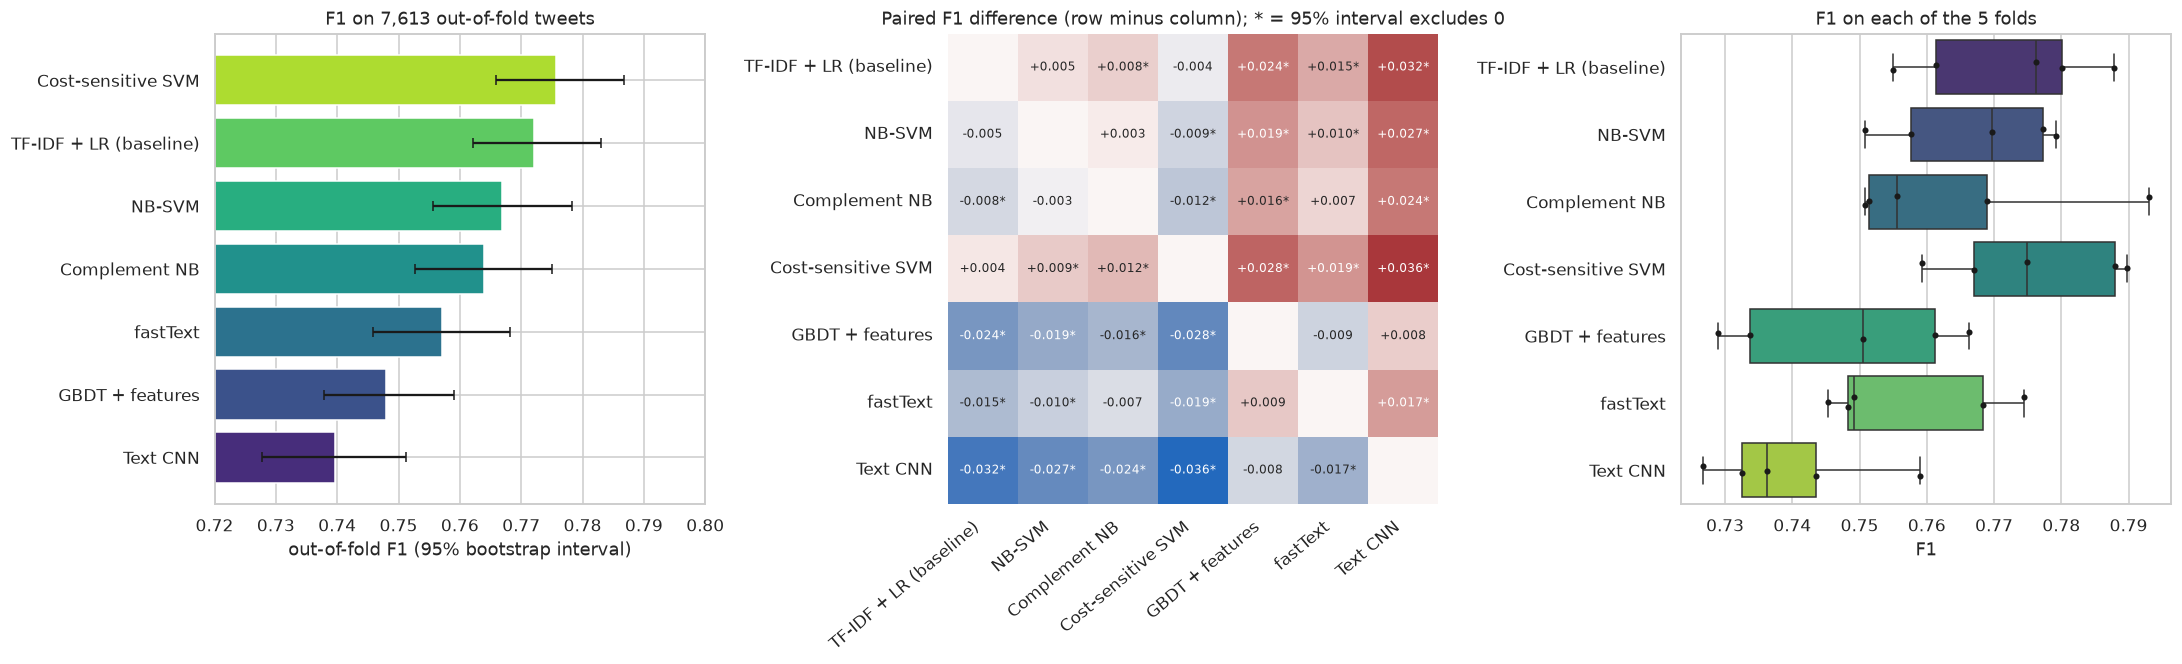

significant pairs (95% paired interval excludes 0): [('TF-IDF + LR (baseline)', 'Complement NB', np.float64(0.0081)), ('TF-IDF + LR (baseline)', 'GBDT + features', np.float64(0.0239)), ('TF-IDF + LR (baseline)', 'fastText', np.float64(0.0149)), ('TF-IDF + LR (baseline)', 'Text CNN', np.float64(0.0323)), ('NB-SVM', 'Cost-sensitive SVM', np.float64(-0.0088)), ('NB-SVM', 'GBDT + features', np.float64(0.0189)), ('NB-SVM', 'fastText', np.float64(0.0099)), ('NB-SVM', 'Text CNN', np.float64(0.0273)), ('Complement NB', 'Cost-sensitive SVM', np.float64(-0.0118)), ('Complement NB', 'GBDT + features', np.float64(0.0158)), ('Complement NB', 'Text CNN', np.float64(0.0242)), ('Cost-sensitive SVM', 'GBDT + features', np.float64(0.0277)), ('Cost-sensitive SVM', 'fastText', np.float64(0.0186)), ('Cost-sensitive SVM', 'Text CNN', np.float64(0.036)), ('fastText', 'Text CNN', np.float64(0.0174))]


In [2]:
order = tab.sort_values("F1").index; keys = {v: k for k, v in NAMES.items()}
pm = np.zeros((7, 7)); pl = np.zeros((7, 7)); ph = np.zeros((7, 7)); pp = np.ones((7, 7)); ks = list(NAMES)
for i, a in enumerate(ks):
    for j, b in enumerate(ks):
        if i != j:
            d, (lo, hi), pv = N.paired_bootstrap_f1(y, PRED[a], PRED[b], n=2000, seed=0); pm[i, j], pl[i, j], ph[i, j], pp[i, j] = d, lo, hi, pv
fig, axes = plt.subplots(1, 3, figsize=(20, 6.2))
axes[0].barh([n for n in order], tab.loc[order, "F1"], xerr=[tab.loc[order, "F1"] - tab.loc[order, "F1_low"], tab.loc[order, "F1_high"] - tab.loc[order, "F1"]], color=sns.color_palette("viridis", 7), capsize=3)
axes[0].set_xlim(0.72, 0.80); axes[0].set_xlabel("out-of-fold F1 (95% bootstrap interval)"); axes[0].set_title("F1 on 7,613 out-of-fold tweets")
sig = (pl > 0) | (ph < 0); lab = np.where(np.eye(7, dtype=bool), "", np.vectorize(lambda d, s: f"{d:+.3f}{'*' if s else ''}")(pm, sig))
sns.heatmap(pd.DataFrame(pm, index=[NAMES[k] for k in ks], columns=[NAMES[k] for k in ks]), annot=lab, fmt="", cmap="vlag", center=0, ax=axes[1], cbar=False, annot_kws={"size": 8})
axes[1].set_title("Paired F1 difference (row minus column); * = 95% interval excludes 0"); plt.setp(axes[1].get_xticklabels(), rotation=40, ha="right")
fp_ = pd.DataFrame({NAMES[k]: EV[k]["fold_f1"] for k in ks}); sns.boxplot(data=fp_, ax=axes[2], orient="h", palette="viridis"); sns.stripplot(data=fp_, ax=axes[2], orient="h", color="k", size=4)
axes[2].set_title("F1 on each of the 5 folds"); axes[2].set_xlabel("F1")
plt.tight_layout(); plt.savefig("assets/cmp_01_f1_and_paired_tests.png", bbox_inches="tight"); plt.show()
print("significant pairs (95% paired interval excludes 0):", [(NAMES[a], NAMES[b], round(pm[i, j], 4)) for i, a in enumerate(ks) for j, b in enumerate(ks) if i < j and ((pl[i, j] > 0) or (ph[i, j] < 0))])

## 2. Do the models make different mistakes?

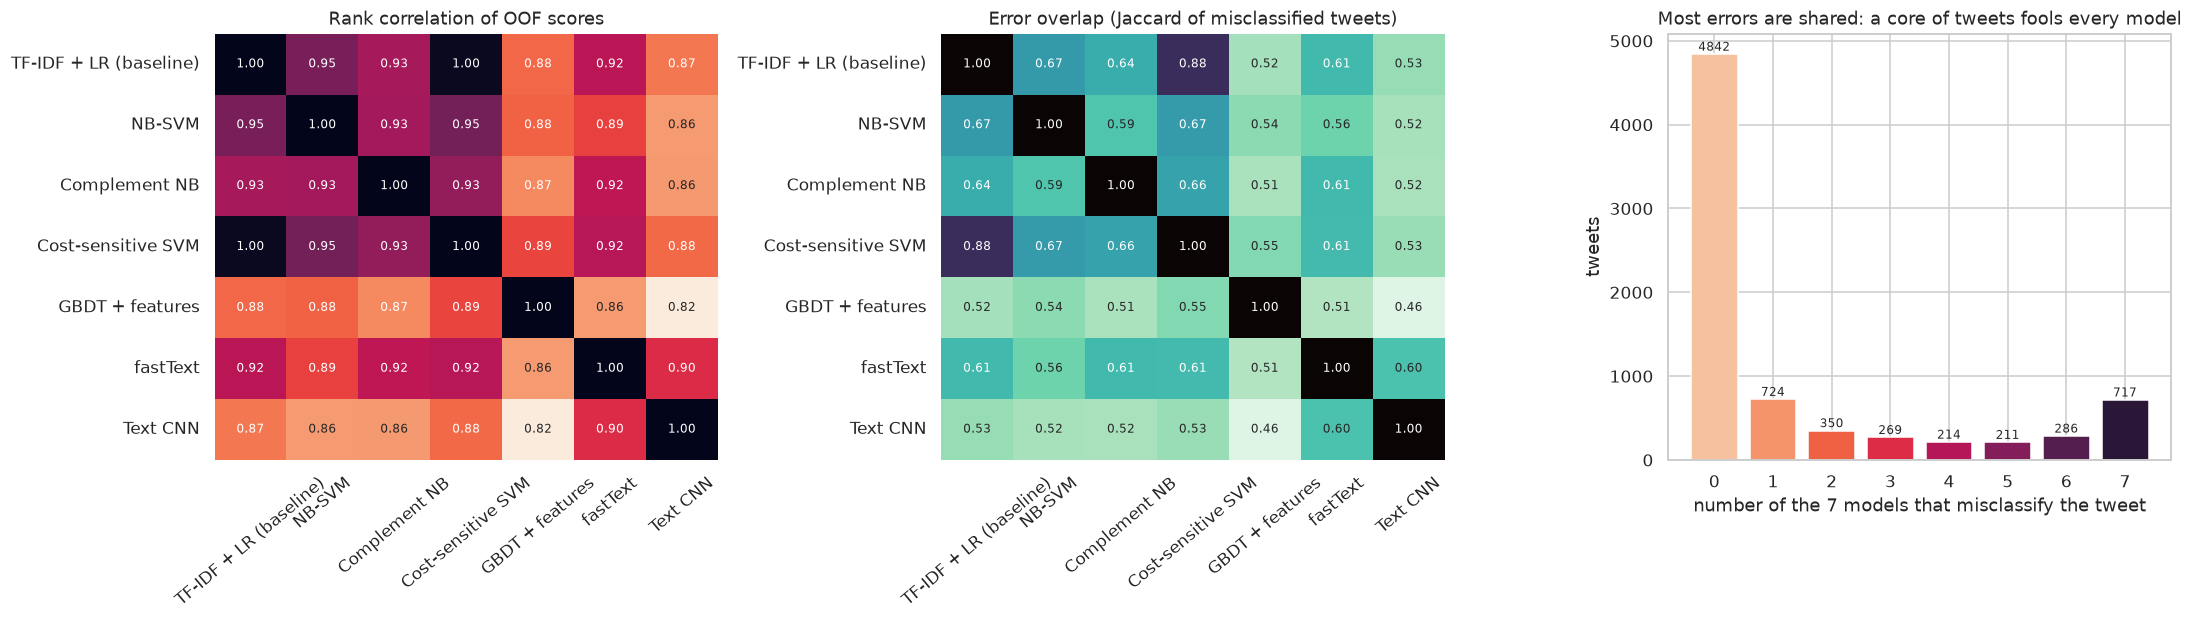

tweets every model gets wrong: 717 (9.4%); tweets at least one model gets right: 90.6% (oracle ceiling); mean single-model accuracy 79.6%


In [3]:
R = pd.DataFrame(Z).rank().corr(method="spearman"); wrong = pd.DataFrame({NAMES[k]: (PRED[k] != y) for k in ks}); n_wrong = wrong.sum(1)
jac = pd.DataFrame([[ (wrong.iloc[:, i] & wrong.iloc[:, j]).sum() / max((wrong.iloc[:, i] | wrong.iloc[:, j]).sum(), 1) for j in range(7)] for i in range(7)], index=wrong.columns, columns=wrong.columns)
fig, axes = plt.subplots(1, 3, figsize=(20, 5.8))
sns.heatmap(R.rename(index=NAMES, columns=NAMES), annot=True, fmt=".2f", cmap="rocket_r", ax=axes[0], cbar=False, annot_kws={"size": 8}); axes[0].set_title("Rank correlation of OOF scores"); axes[0].tick_params(axis="x", rotation=40)
sns.heatmap(jac, annot=True, fmt=".2f", cmap="mako_r", ax=axes[1], cbar=False, annot_kws={"size": 8}); axes[1].set_title("Error overlap (Jaccard of misclassified tweets)"); axes[1].tick_params(axis="x", rotation=40)
cnt = n_wrong.value_counts().sort_index(); axes[2].bar(cnt.index, cnt.values, color=sns.color_palette("rocket_r", len(cnt))); axes[2].set_xlabel("number of the 7 models that misclassify the tweet"); axes[2].set_ylabel("tweets")
axes[2].set_title("Most errors are shared: a core of tweets fools every model")
for x_, v_ in zip(cnt.index, cnt.values): axes[2].text(x_, v_ + 40, f"{v_}", ha="center", fontsize=8)
plt.tight_layout(); plt.savefig("assets/cmp_02_diversity.png", bbox_inches="tight"); plt.show()
oracle = (wrong.sum(1) < 7).mean(); print(f"tweets every model gets wrong: {(n_wrong == 7).sum()} ({(n_wrong == 7).mean():.1%}); tweets at least one model gets right: {oracle:.1%} (oracle ceiling); mean single-model accuracy {1 - wrong.mean().mean():.1%}")

## 3. Stacking

Each model's OOF score is put on a common scale (logit for probabilities, otherwise the raw margin, then z-scored with the OOF mean
and standard deviation). A logistic regression combines them. $\mathrm{logit}\,P(y{=}1)=b+\sum_m w_m z_m$, with $C$ chosen by an inner
cross-validation. Because every $z_m$ is standardised, $|w_m|$ is comparable across models.

In [4]:
M = np.column_stack([Z[k] for k in ks]); MT = np.column_stack([ZT[k] for k in ks])
def stack_oof(cols, C=0.3, seeds=(123, 456, 789)):
    out = np.zeros(len(y))
    for sd in seeds:
        for tr, va in StratifiedKFold(5, shuffle=True, random_state=sd).split(M, y):
            out[va] += LogisticRegression(C=C, max_iter=1000).fit(M[tr][:, cols], y[tr]).decision_function(M[va][:, cols]) / len(seeds)
    return out
sweepC = {C_: roc_auc_score(y, stack_oof(list(range(7)), C_, seeds=(123,))) for C_ in [0.01, 0.03, 0.1, 0.3, 1, 3]}; Cbest = max(sweepC, key=sweepC.get); print("stacker C -> AUC:", {k: round(v, 4) for k, v in sweepC.items()}, "-> C =", Cbest)
st = stack_oof(list(range(7)), Cbest); ev_st = N.evaluate(y, st, folds); pred_st = (st > ev_st["threshold"]).astype(int)
best_single = max(ks, key=lambda k: EV[k]["f1"]); d, (lo, hi), pv = N.paired_bootstrap_f1(y, pred_st, PRED[best_single], n=4000, seed=1)
d0, (lo0, hi0), pv0 = N.paired_bootstrap_f1(y, pred_st, PRED["tfidf_lr"], n=4000, seed=2)
print(f"STACK: AUC {ev_st['auc']:.4f}  F1 {ev_st['f1']:.4f} {np.round(ev_st['f1_ci95'], 4)}  precision {ev_st['precision']:.3f} recall {ev_st['recall']:.3f}")
print(f"vs best single ({NAMES[best_single]}, F1 {EV[best_single]['f1']:.4f}): diff {d:+.4f} [{lo:+.4f}, {hi:+.4f}], P(diff<=0) = {pv:.3f}")
print(f"vs TF-IDF LR baseline: diff {d0:+.4f} [{lo0:+.4f}, {hi0:+.4f}], P(diff<=0) = {pv0:.3f}")
full = LogisticRegression(C=Cbest, max_iter=1000).fit(M, y); coef = pd.Series(full.coef_[0], index=[NAMES[k] for k in ks]).sort_values(); print("stack weights:", coef.round(3).to_dict(), "intercept", round(float(full.intercept_[0]), 3))

stacker C -> AUC: {0.01: 0.8747, 0.03: 0.8748, 0.1: 0.8748, 0.3: 0.8747, 1: 0.8747, 3: 0.8747} -> C = 0.03


STACK: AUC 0.8748  F1 0.7752 [0.7641 0.7869]  precision 0.804 recall 0.748
vs best single (Cost-sensitive SVM, F1 0.7757): diff -0.0005 [-0.0052, +0.0042], P(diff<=0) = 0.584
vs TF-IDF LR baseline: diff +0.0031 [-0.0019, +0.0080], P(diff<=0) = 0.102
stack weights: {'Text CNN': 0.138, 'fastText': 0.175, 'GBDT + features': 0.205, 'Complement NB': 0.265, 'NB-SVM': 0.403, 'Cost-sensitive SVM': 0.503, 'TF-IDF + LR (baseline)': 0.508} intercept -0.266


,F1,AUC,F1 drop
TF-IDF + LR (baseline),0.7762,0.8744,-0.0010
NB-SVM,0.7741,0.8747,0.0011
Complement NB,0.7757,0.8750,-0.0006
Cost-sensitive SVM,0.7759,0.8745,-0.0007
GBDT + features,0.7743,0.8745,0.0008
fastText,0.7759,0.8747,-0.0007
Text CNN,0.7762,0.8749,-0.0011


,added,AUC,F1
0,Cost-sensitive SVM,0.8742,0.7754
1,fastText,0.8744,0.7742
2,NB-SVM,0.8747,0.7766
3,TF-IDF + LR (baseline),0.8749,0.7752
4,GBDT + features,0.8751,0.7755
5,Text CNN,0.8750,0.7757
6,Complement NB,0.8748,0.7752


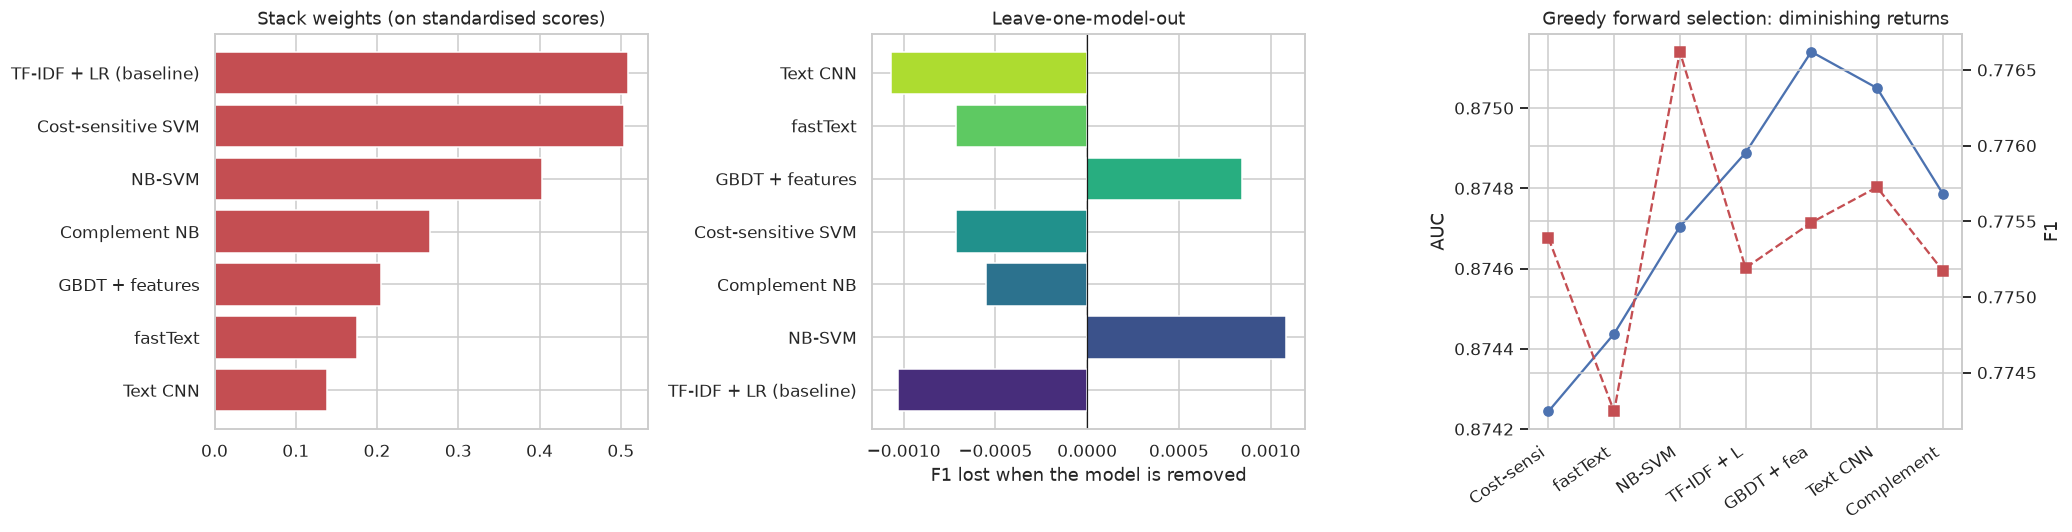

In [5]:
loo = {}
for j, k in enumerate(ks):
    cols = [c for c in range(7) if c != j]; o = stack_oof(cols, Cbest, seeds=(123,)); e = N.evaluate(y, o, folds, n_boot=50); loo[NAMES[k]] = (e["f1"], e["auc"])
loo = pd.DataFrame(loo, index=["F1", "AUC"]).T; loo["F1 drop"] = ev_st["f1"] - loo["F1"]
# greedy forward selection by OOF AUC: how many members are needed?
chosen, rem, path = [], list(range(7)), []
while rem:
    j = max(rem, key=lambda c: roc_auc_score(y, stack_oof(chosen + [c], Cbest, seeds=(123,)))); chosen.append(j); rem.remove(j)
    o = stack_oof(chosen, Cbest, seeds=(123,)); path.append((NAMES[ks[j]], roc_auc_score(y, o), N.evaluate(y, o, folds, n_boot=20)["f1"]))
path = pd.DataFrame(path, columns=["added", "AUC", "F1"]); display(loo.round(4)); display(path.round(4))
fig, axes = plt.subplots(1, 3, figsize=(19, 5))
axes[0].barh(coef.index, coef.values, color=["#C44E52" if v > 0 else "#4C72B0" for v in coef.values]); axes[0].set_title("Stack weights (on standardised scores)")
axes[1].barh(loo.index, loo["F1 drop"], color=sns.color_palette("viridis", 7)); axes[1].axvline(0, color="k", lw=.8); axes[1].set_xlabel("F1 lost when the model is removed"); axes[1].set_title("Leave-one-model-out")
axes[2].plot(range(1, 8), path.AUC, "o-", label="AUC"); ax2 = axes[2].twinx(); ax2.plot(range(1, 8), path.F1, "s--", color="#C44E52", label="F1"); axes[2].set_xticks(range(1, 8), [a[:10] for a in path.added], rotation=35, ha="right")
axes[2].set_ylabel("AUC"); ax2.set_ylabel("F1"); axes[2].set_title("Greedy forward selection: diminishing returns")
plt.tight_layout(); plt.savefig("assets/cmp_03_stacking.png", bbox_inches="tight"); plt.show()

## 4. Final model: diagnostics

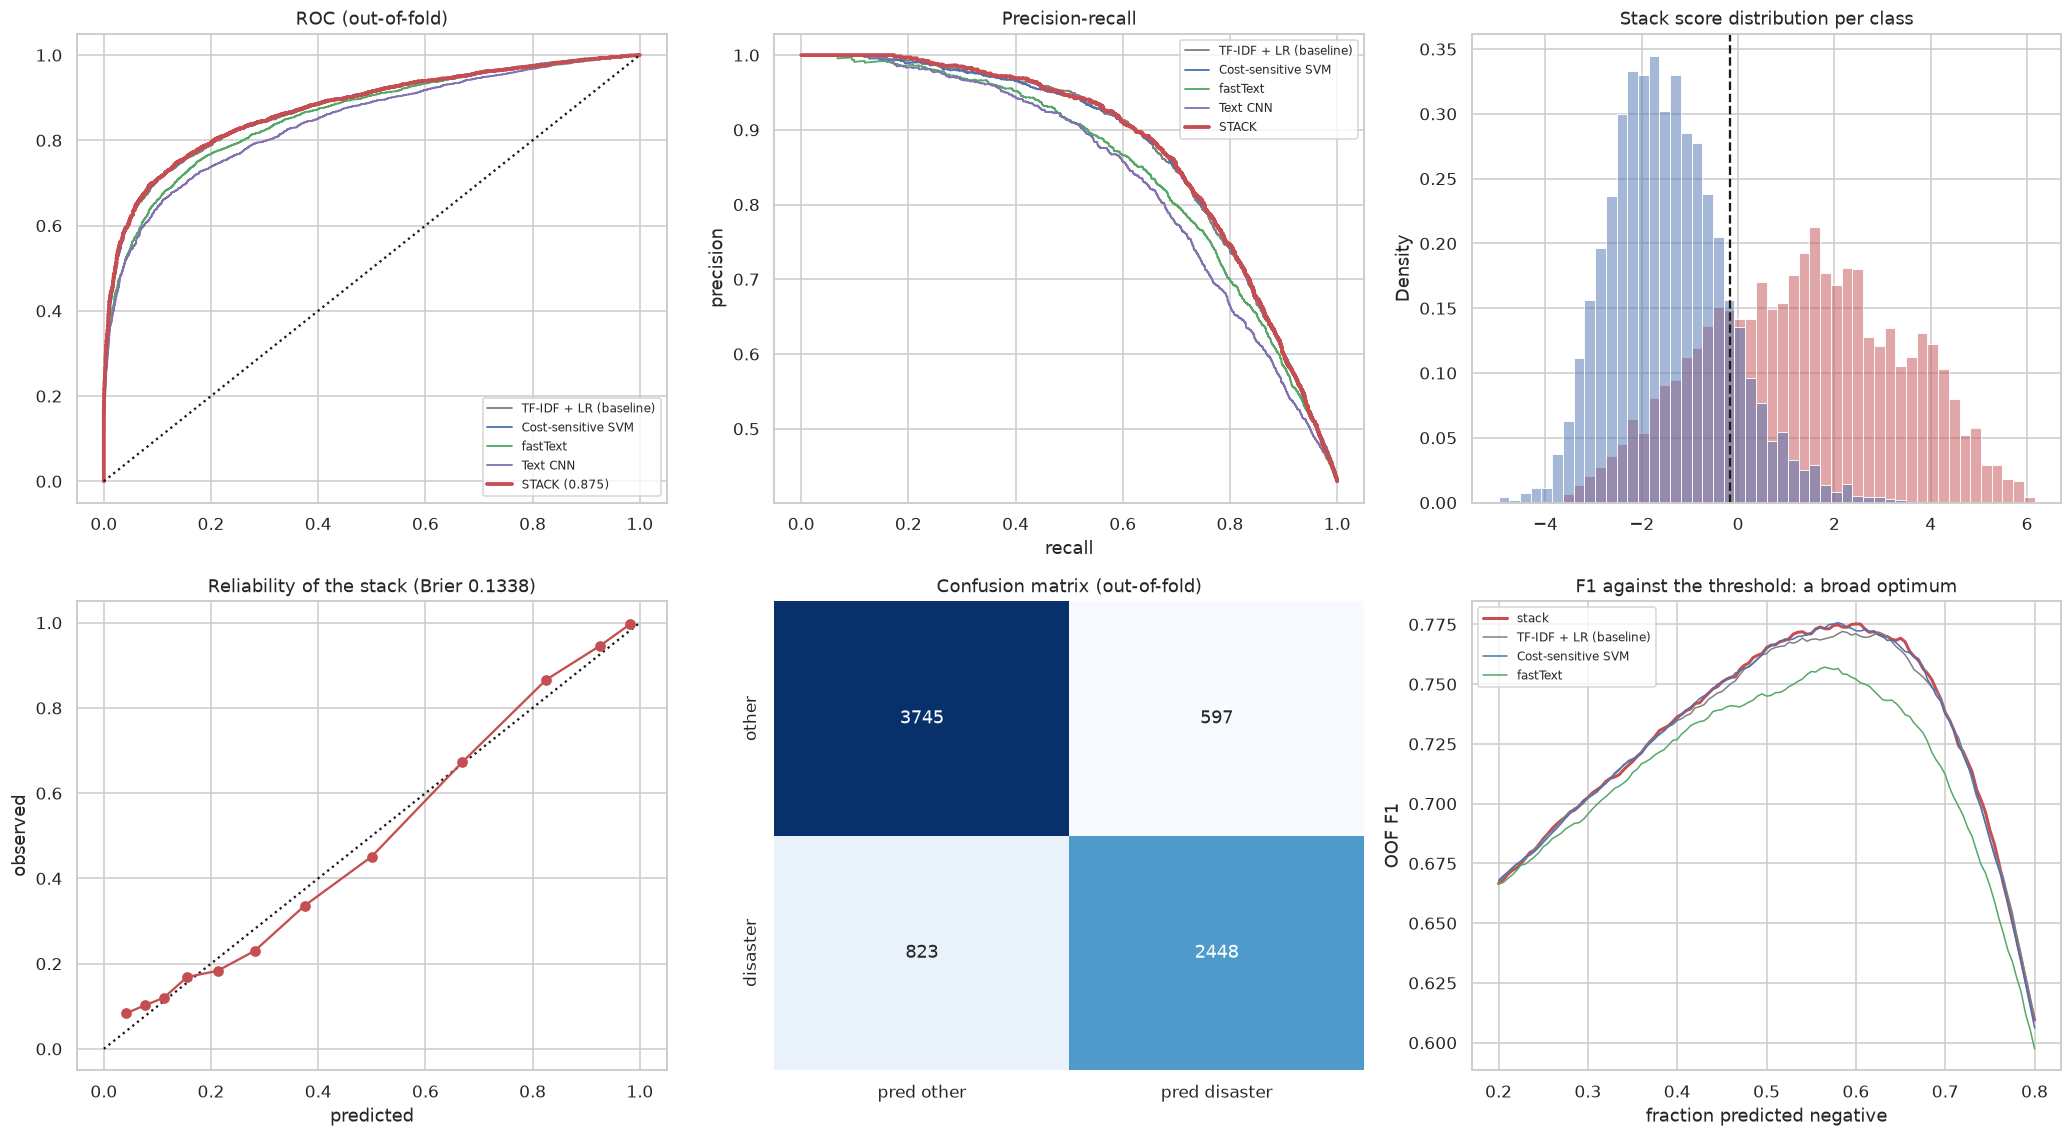

In [6]:
th = ev_st["threshold"]; fig, axes = plt.subplots(2, 3, figsize=(19, 10.5))
for k, c in zip(["tfidf_lr", "svm_cost", "fasttext", "textcnn"], ["grey", "#4C72B0", "#55A868", "#8172B2"]):
    f, t, _ = roc_curve(y, Z[k]); axes[0, 0].plot(f, t, color=c, lw=1.2, label=NAMES[k]); pr, rc, _ = precision_recall_curve(y, Z[k]); axes[0, 1].plot(rc, pr, color=c, lw=1.2, label=NAMES[k])
f, t, _ = roc_curve(y, st); axes[0, 0].plot(f, t, color="#C44E52", lw=2.5, label=f"STACK ({ev_st['auc']:.3f})"); pr, rc, _ = precision_recall_curve(y, st); axes[0, 1].plot(rc, pr, color="#C44E52", lw=2.5, label="STACK")
axes[0, 0].plot([0, 1], [0, 1], "k:"); axes[0, 0].legend(fontsize=8); axes[0, 0].set_title("ROC (out-of-fold)"); axes[0, 1].legend(fontsize=8); axes[0, 1].set_title("Precision-recall"); axes[0, 1].set_xlabel("recall"); axes[0, 1].set_ylabel("precision")
sns.histplot(x=st, hue=y, bins=50, stat="density", common_norm=False, palette=["#4C72B0", "#C44E52"], ax=axes[0, 2], legend=False); axes[0, 2].axvline(th, color="k", ls="--"); axes[0, 2].set_title("Stack score distribution per class")
p_st = N.sigmoid(st); fp, mp = calibration_curve(y, p_st, n_bins=12, strategy="quantile"); axes[1, 0].plot([0, 1], [0, 1], "k:"); axes[1, 0].plot(mp, fp, "o-", color="#C44E52"); axes[1, 0].set_title(f"Reliability of the stack (Brier {brier_score_loss(y, p_st):.4f})"); axes[1, 0].set_xlabel("predicted"); axes[1, 0].set_ylabel("observed")
cm = confusion_matrix(y, pred_st); sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[1, 1], cbar=False, xticklabels=["pred other", "pred disaster"], yticklabels=["other", "disaster"]); axes[1, 1].set_title("Confusion matrix (out-of-fold)")
ths = np.quantile(st, np.linspace(0.2, 0.8, 121)); axes[1, 2].plot(np.linspace(0.2, 0.8, 121), [f1_score(y, st > t) for t in ths], color="#C44E52", lw=2, label="stack")
for k, c in zip(["tfidf_lr", "svm_cost", "fasttext"], ["grey", "#4C72B0", "#55A868"]): axes[1, 2].plot(np.linspace(0.2, 0.8, 121), [f1_score(y, Z[k] > t) for t in np.quantile(Z[k], np.linspace(0.2, 0.8, 121))], color=c, lw=1, label=NAMES[k])
axes[1, 2].set_xlabel("fraction predicted negative"); axes[1, 2].set_ylabel("OOF F1"); axes[1, 2].set_title("F1 against the threshold: a broad optimum"); axes[1, 2].legend(fontsize=8)
plt.tight_layout(); plt.savefig("assets/cmp_04_final_diagnostics.png", bbox_inches="tight"); plt.show()

## 5. Where every model fails: error analysis

Slice error rates by tweet properties, then read the most confident mistakes of the stack.

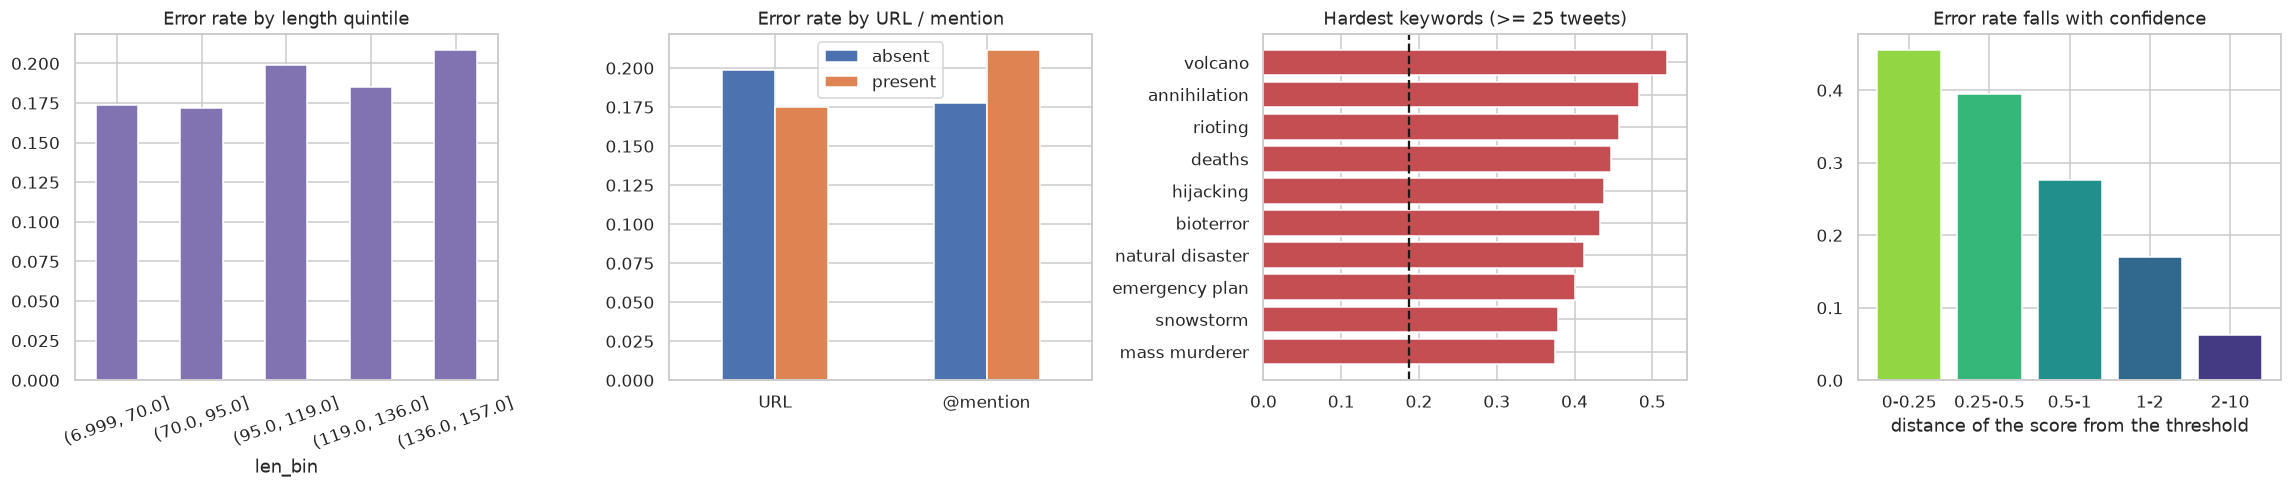

Most confident false positives (labelled not-disaster):


,keyword,text,score
5641,refugees,wowo--=== 12000 Nigerian refugees repatriated from Cameroon,3.422969
5113,nuclear%20disaster,Over half of poll respondents worry nuclear disaster fading from public consciousness http://t.co/YtnnnD631z ##fukus...,3.309365
3057,earthquake,#Sismo M 1.3 - 1km NNE of The Geysers California: Time2015-08-05 23:40:21 UTC2015-08-05 16:40:21 -07:00 a... http://...,3.165961
3343,evacuated,Trafford Centre film fans angry after Odeon cinema evacuated following false fire alarm http://t.co/6GLDwx71DA,3.078453
3363,evacuation,FAAN orders evacuation of abandoned aircraft at MMA http://t.co/dEvYbnVXGQ via @todayng,3.069138
5435,police,Maid charged with stealing Dh30000 from police officer sponsor http://t.co/y35qtVDSOH | https://t.co/qhUJAjCTR5,2.985750
2832,displaced,.POTUS #StrategicPatience is a strategy for #Genocide; refugees; IDP Internally displaced people; horror; etc. https...,2.923994
397,arson,Mourning notices for stabbing arson victims stir Û÷politics of griefÛª in Israel: Posters for Shira Banki and A......,2.908502


Most confident false negatives (labelled disaster):


,keyword,text,score
974,body%20bag,?? New Ladies Shoulder Tote #Handbag Faux Leather Hobo Purse Cross Body Bag #Womens http://t.co/zujwUiomb3 http://t....,-4.331770
4154,harm,You can never escape me. Bullets don't harm me. Nothing harms me. But I know pain. I know pain. Sometimes I share it...,-4.265133
649,blaze,Love living on my own. I can blaze inside my apt or on the balcony,-3.866922
5411,panicking,all that panicking made me tired ;__; i want to sleep in my bed,-3.621065
4732,lava,Check out my Lava lamp dude ???? http://t.co/To9ViqooFv,-3.553354
4143,harm,@leedsrouge Love what you picked! We're playing WORTH IT by FIFTH HARM/KID INK because of you! Listen &amp; Vote: ht...,-3.552190
2905,drown,I can't drown my demons they know how to swim,-3.524776
6108,sinking,Do you feel like you are sinking in low self-image? Take the quiz: http://t.co/bJoJVM0pjX http://t.co/wHOc7LHb5F,-3.524252


error rate on tweets whose duplicates disagree: 58.2% (n=55); elsewhere 18.4%


In [7]:
E = train.assign(score=st, pred=pred_st, wrong=(pred_st != y), n_wrong=n_wrong.values, chars=train.text.str.len())
E["has_url"] = E.text.str.contains("http"); E["has_mention"] = E.text.str.contains("@"); E["len_bin"] = pd.qcut(E.chars, 5); E["kw"] = E.keyword.isna().map({True: "keyword missing", False: "keyword given"})
dup = train.groupby("text").target.transform("nunique") > 1; E["conflict"] = dup.map({True: "duplicate, labels disagree", False: "other"})
fig, axes = plt.subplots(1, 4, figsize=(21, 4.6))
E.groupby("len_bin", observed=True).wrong.mean().plot.bar(ax=axes[0], rot=20, color="#8172B2"); axes[0].set_title("Error rate by length quintile")
pd.DataFrame({"URL": E.groupby("has_url").wrong.mean(), "@mention": E.groupby("has_mention").wrong.mean()}).T.rename(columns={False: "absent", True: "present"}).plot.bar(ax=axes[1], rot=0); axes[1].set_title("Error rate by URL / mention")
kwe = E.dropna(subset=["keyword"]).groupby("keyword").agg(n=("wrong", "size"), err=("wrong", "mean")).query("n >= 25").sort_values("err").tail(10); axes[2].barh(kwe.index.str.replace("%20", " "), kwe.err, color="#C44E52"); axes[2].axvline(E.wrong.mean(), color="k", ls="--"); axes[2].set_title("Hardest keywords (>= 25 tweets)")
conf_ = pd.cut(np.abs(st - th), [0, .25, .5, 1, 2, 10]); acc = E.groupby(conf_, observed=True).wrong.agg(["mean", "size"]); axes[3].bar(range(len(acc)), acc["mean"], color=sns.color_palette("viridis_r", len(acc))); axes[3].set_xticks(range(len(acc)), [f"{i.left:g}-{i.right:g}" for i in acc.index]); axes[3].set_xlabel("distance of the score from the threshold"); axes[3].set_title("Error rate falls with confidence")
plt.tight_layout(); plt.savefig("assets/cmp_05_error_slices.png", bbox_inches="tight"); plt.show()
pd.set_option("display.max_colwidth", 120); print("Most confident false positives (labelled not-disaster):"); display(E[E.target == 0].nlargest(8, "score")[["keyword", "text", "score"]])
print("Most confident false negatives (labelled disaster):"); display(E[E.target == 1].nsmallest(8, "score")[["keyword", "text", "score"]])
print(f"error rate on tweets whose duplicates disagree: {E[E.conflict != 'other'].wrong.mean():.1%} (n={int((E.conflict != 'other').sum())}); elsewhere {E[E.conflict == 'other'].wrong.mean():.1%}")

## 6. Submission

Base models' test scores (each the average of its five fold models) are standardised with the OOF mean and standard deviation,
combined by the stack, and thresholded at the OOF-optimal value. Sanity checks: the predicted positive rate on the test set
should resemble the OOF rate, and the test score distribution should resemble the OOF one.

positive rate: OOF predicted 0.4000, train labels 0.4297, test predicted 0.3874
per-model test/OOF mean score ratio (z-scale): {'TF-IDF + LR ': -0.009, 'NB-SVM': -0.019, 'Complement N': -0.031, 'Cost-sensiti': -0.014, 'GBDT + featu': -0.017, 'fastText': -0.025, 'Text CNN': -0.024}
KS test OOF vs test stack scores: D=0.019, p=0.386


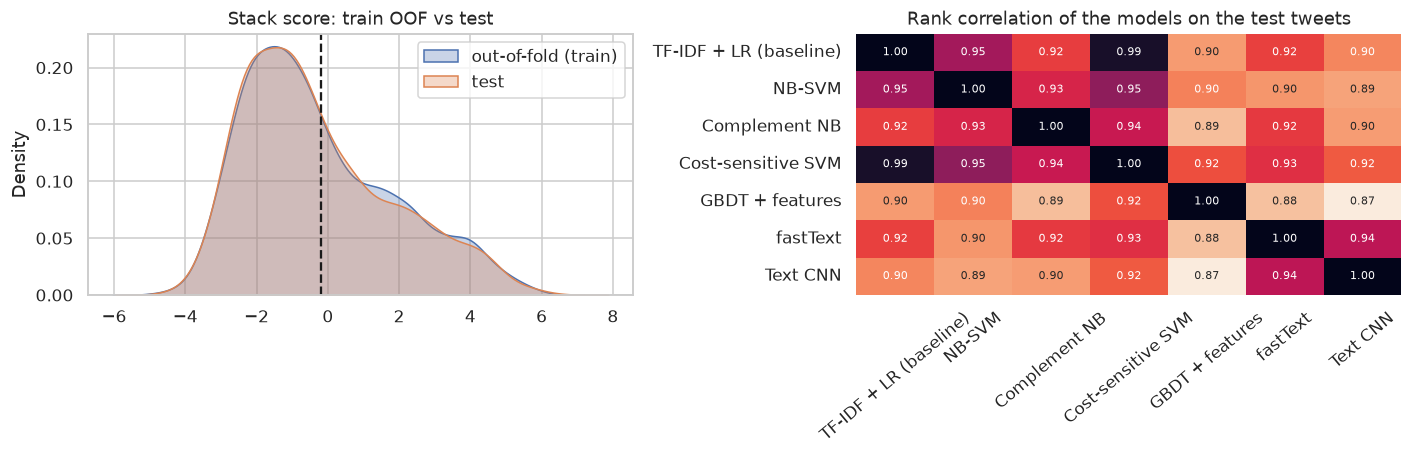

written submission_stack.csv (3263,) and submission_svm_cost.csv


In [8]:
mt = full.decision_function(MT); pred_te = (mt > th).astype(int)
print(f"positive rate: OOF predicted {pred_st.mean():.4f}, train labels {y.mean():.4f}, test predicted {pred_te.mean():.4f}")
print(f"per-model test/OOF mean score ratio (z-scale): { {NAMES[k][:12]: round(float(ZT[k].mean()), 3) for k in ks} }")
ks_stat, ks_p = stats.ks_2samp(st, mt); print(f"KS test OOF vs test stack scores: D={ks_stat:.3f}, p={ks_p:.3g}")
fig, axes = plt.subplots(1, 2, figsize=(13, 4.3)); sns.kdeplot(st, ax=axes[0], label="out-of-fold (train)", fill=True, alpha=.3); sns.kdeplot(mt, ax=axes[0], label="test", fill=True, alpha=.3); axes[0].axvline(th, color="k", ls="--"); axes[0].legend(); axes[0].set_title("Stack score: train OOF vs test")
sns.heatmap(pd.DataFrame(ZT, columns=ks).rename(columns=NAMES).corr(method="spearman"), annot=True, fmt=".2f", cmap="rocket_r", ax=axes[1], cbar=False, annot_kws={"size": 7}); axes[1].set_title("Rank correlation of the models on the test tweets"); axes[1].tick_params(axis="x", rotation=40)
plt.tight_layout(); plt.savefig("assets/cmp_06_test_sanity.png", bbox_inches="tight"); plt.show()
sample = pd.read_csv("data/sample_submission.csv"); assert (sample.id.values == test.id.values).all()
pd.DataFrame({"id": test.id, "target": pred_te}).to_csv("submission_stack.csv", index=False)
pd.DataFrame({"id": test.id, "target": (ZT[best_single] > EV[best_single]["threshold"]).astype(int)}).to_csv(f"submission_{best_single}.csv", index=False)
json.dump(dict(stack=dict(auc=ev_st["auc"], f1=ev_st["f1"], f1_ci95=ev_st["f1_ci95"], threshold=th, C=Cbest, weights=coef.to_dict(), precision=ev_st["precision"], recall=ev_st["recall"]),
               best_single=dict(name=best_single, **{k: EV[best_single][k] for k in ["auc", "f1", "f1_ci95"]}), table=tab.to_dict("index"), paired_vs_best_single=dict(diff=d, ci=[lo, hi], p_le_0=pv)), open("results/comparison_summary.json", "w"), indent=2, default=float)
print("written submission_stack.csv", pred_te.shape, "and submission_%s.csv" % best_single)